# Strong Scaling - Container

Container SIDE + native comparison.

This experiment focus on the strong scaling.\
We fix $N$, vary $P$. Sample sort has $O(NlogN/P)$ local work and $O(N)$ aggregate communication; communication will dominate eventually. Find the cross-over for your machine.

The experiment focus mostly on **MPI** level (since **k** literally is the number of MPI ranks). The number of **OMP threads** are fixed to 1. The number of **MPI ranks** increase exponentially from **4** to **256**. Here are reported the common configurations across all the runs:

* **n_bits** : $64$
* **n_keys** : $10^9$
* **n_threads** : $1$
* **keys_distribution** : uniform
* **sorting_strategy** : radix
* **merging_strategy** : bin

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metrics here are **time_comunication_seconds** and **total_seconds**.

In [8]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [9]:
native_results = pd.read_csv("../parallel/results/strong_scaling.csv")
native_results = native_results[
    ["n_key","n_ranks", "distribution", "time_communication_seconds", "time_total_seconds"]
]
native_results["version"] = "native"
native_results.head()

,n_key,n_ranks,distribution,time_communication_seconds,time_total_seconds,version
0,1000000000,4,uniform,3.768309,27.171625,native
1,1000000000,8,uniform,2.682844,15.270281,native
2,1000000000,16,uniform,2.001842,8.724568,native
3,1000000000,32,uniform,1.963315,5.944329,native
4,1000000000,64,uniform,1.347721,3.606978,native


In [10]:
container_results = pd.read_csv("../parallel/results/container_strong_scaling.csv")
container_results = container_results[
    ["n_key", "n_ranks", "distribution", "time_communication_seconds", "time_total_seconds"]
]
container_results["version"] = "container"
container_results.head()

,n_key,n_ranks,distribution,time_communication_seconds,time_total_seconds,version
0,1000000000,4,uniform,4.442903,27.186175,container
1,1000000000,8,uniform,2.792261,14.515000,container
2,1000000000,16,uniform,2.221478,8.836068,container
3,1000000000,32,uniform,2.142592,6.026655,container
4,1000000000,64,uniform,1.397335,3.836387,container


In [11]:
results = pd.merge(native_results, container_results, "outer")
results.head(30)

,n_key,n_ranks,distribution,time_communication_seconds,time_total_seconds,version
0,1000000000,4,uniform,3.527788,27.369058,native
1,1000000000,4,uniform,3.531147,27.316242,native
2,1000000000,4,uniform,3.768309,27.171625,native
3,1000000000,4,uniform,3.809515,26.976005,native
4,1000000000,4,uniform,4.442903,27.186175,container
5,1000000000,4,uniform,4.548952,27.486579,container
6,1000000000,4,uniform,4.680138,27.260174,container
7,1000000000,4,uniform,4.685256,27.130142,container
8,1000000000,8,uniform,2.661945,15.406119,native
9,1000000000,8,uniform,2.682844,15.270281,native


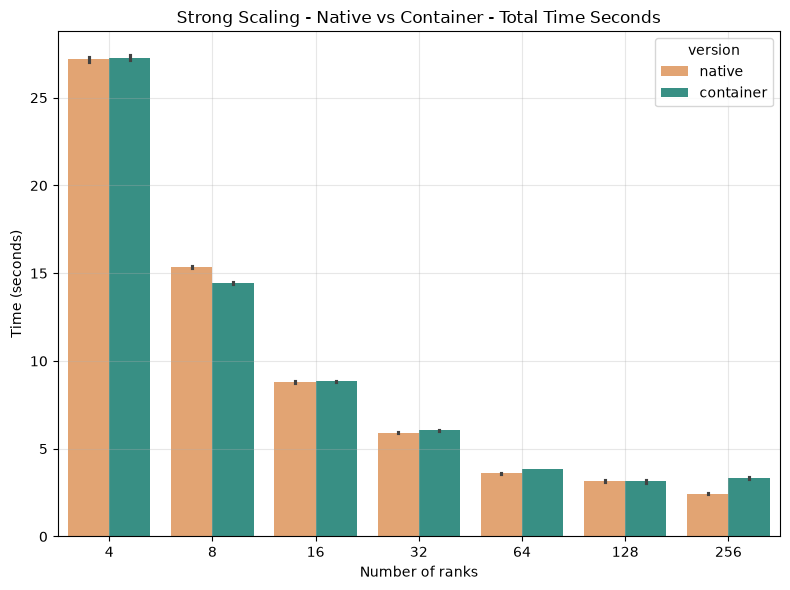

In [14]:
custom_palette = {
    "container": "#2a9d8f",
    "native": "#f4a261"
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="n_ranks",
    y="time_total_seconds",
    hue="version",
    palette=custom_palette,
    legend=True
)

plt.xlabel("Number of ranks")
plt.ylabel("Time (seconds)")
plt.title(f"Strong Scaling - Native vs Container - Total Time Seconds")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()